# Exploratory Data Analysis (EDA)

> **Purpose (experiment-driven EDA)**  
> This EDA is intentionally scoped to support causal A/B experiment analysis.
>
> The goals are to:
> - Verify data quality and unit of analysis (event → session)
> - Check UI variant exposure balance (A/B validity)
> - Understand engagement distributions and outliers (robustness)
> - Assess engagement–conversion relationship (HTE motivation)
>
> Every plot or table in this notebook is designed to support downstream
> experiment validity or decision-making.


## 1. Data Overview & Unit of Analysis

The raw data consists of **event-level logs**.  
Since the experiment is randomized at the **session level**, we first inspect
the raw schema and then construct a session-level table aligned with the
experiment unit.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

In [2]:
PATH = "../data/visit.csv"  

df = pd.read_csv(
    PATH,
    nrows=200_000,         
    sep=None,
    engine="python",
    encoding="latin1",
    on_bad_lines="skip",
)



# Basic shape and schema
print("raw df shape:", df.shape)
df.head()


raw df shape: (200000, 14)


,session_token,session_fingerprint,session_userToken,session_siteId,session_userId,visit_url,visit_type,visit_group,visit_category,visit_action,visit_name,visit_time,visit_visitKey,visit_groupSource
0,2150592,f8743a40576f03f5,NaN,6,ded242a9-155b-4705-b78e-902ac35b1fa8,https://4fstore.lv/zenu-gluds-polo-krekls-4fjs...,event,230401_230612_1686725101__3_default,ProductPage,selectSize,152,2023-07-09 13:37:47,event-ProductPage-selectSize-152-zenu-gluds,default
1,1507298,7f6ae472f1bdefad,NaN,6,NaN,https://4fstore.lv/zenu-pilsetas-virsjaka-4fjs...,product,default,NaN,NaN,NaN,2023-05-20 11:30:12,product-zenu-pilsetas,default
2,1533978,416e82324fcf473b,NaN,6,0a6b0cf5-4c84-418b-a037-d16451b287e8,https://4fstore.lv/viriesu-velosorti-ar-gela-i...,product,default,NaN,NaN,NaN,2023-05-27 19:52:43,product-viriesu-velosorti,default
3,1443657,b0522e87b07575da,NaN,6,NaN,https://4fstore.lv/?click_id=9gyZ1YxXfAZe1z7,other,default,NaN,NaN,NaN,2023-05-02 20:01:07,other,default
4,1373543,368ad8fa76f49c1d,NaN,6,NaN,https://4fstore.lv/sieviesu-neatpogajama-sport...,product,default,NaN,NaN,NaN,2023-04-12 17:54:58,product-sieviesu-neatpogajama,default


In [3]:
df.columns.tolist(), df.dtypes


(['session_token',
  'session_fingerprint',
  'session_userToken',
  'session_siteId',
  'session_userId',
  'visit_url',
  'visit_type',
  'visit_group',
  'visit_category',
  'visit_action',
  'visit_name',
  'visit_time',
  'visit_visitKey',
  'visit_groupSource'],
 session_token           int64
 session_fingerprint    object
 session_userToken      object
 session_siteId          int64
 session_userId         object
 visit_url              object
 visit_type             object
 visit_group            object
 visit_category         object
 visit_action           object
 visit_name             object
 visit_time             object
 visit_visitKey         object
 visit_groupSource      object
 dtype: object)

In [4]:
missing = (df.isna().mean().sort_values(ascending=False) * 100).round(2)
missing

visit_name             94.61
visit_action           91.67
visit_category         91.67
session_userToken      76.54
session_userId         36.38
visit_url               1.12
session_siteId          0.00
session_fingerprint     0.00
session_token           0.00
visit_group             0.00
visit_type              0.00
visit_time              0.00
visit_visitKey          0.00
visit_groupSource       0.00
dtype: float64

## 3. Time Parsing & Duplicates

We ensure timestamps are parsable and check for duplicated event records.


In [5]:
df["visit_time"] = pd.to_datetime(df["visit_time"], errors="coerce")
df["visit_time"].min(), df["visit_time"].max(), df["visit_time"].isna().mean()


(Timestamp('2023-04-01 00:04:12'),
 Timestamp('2023-07-14 23:52:42'),
 np.float64(0.0))

In [6]:
df.duplicated().mean()


np.float64(0.01187)

## 4. High-level Data Card

A compact summary of dataset scale and experimental dimensions.


In [7]:
data_card = {
    "n_events": len(df),
    "n_sessions": df["session_token"].nunique(),
    "n_users": df["session_userId"].nunique(),
    "n_ui_groups": df["visit_group"].nunique(),
    "n_actions": df["visit_action"].nunique(),
}
data_card


{'n_events': 200000,
 'n_sessions': 100357,
 'n_users': 38592,
 'n_ui_groups': 15,
 'n_actions': 7}

## 5. Event-level Sanity Checks

Before aggregation, we inspect the most common actions and UI groups to confirm
expected logging behavior.


In [8]:
df["visit_action"].value_counts().head(30)


visit_action
selectColor       5193
thumbnailClick    5027
selectSize        3400
miniCart          1962
Click              509
imageClick         347
clickAccordion     225
Name: count, dtype: int64

In [9]:
group_counts_events = df["visit_group"].value_counts().head(30)
group_counts_events


visit_group
default                                                             180013
230401_230612_1686725101__lottery_default                             3854
230401_230612_1686725101__lottery                                     3636
230401_230612_1686725101__2                                           2021
230401_230612_1686725101__2_default                                   1875
8783cca2582243602a52eee552472f0856f35ff55c49ca4d97cc61f5d379b740      1875
230401_230612_1686725101__4                                           1127
230401_230612_1686725101__4_default                                   1001
f13213565627e05fcf069a678d30f13ba72c73297b5ca0ec31c679ba29bdeab1       940
230401_230612_1686725101__3_default                                    925
230401_230612_1686725101__3                                            914
4aaa1ff93ba3b7da9e7a22e0874d67d421e9a5cf6aaac2cb99142e0aa882056d       534
230401_230612_1686725101__1                                            514
230401_230612

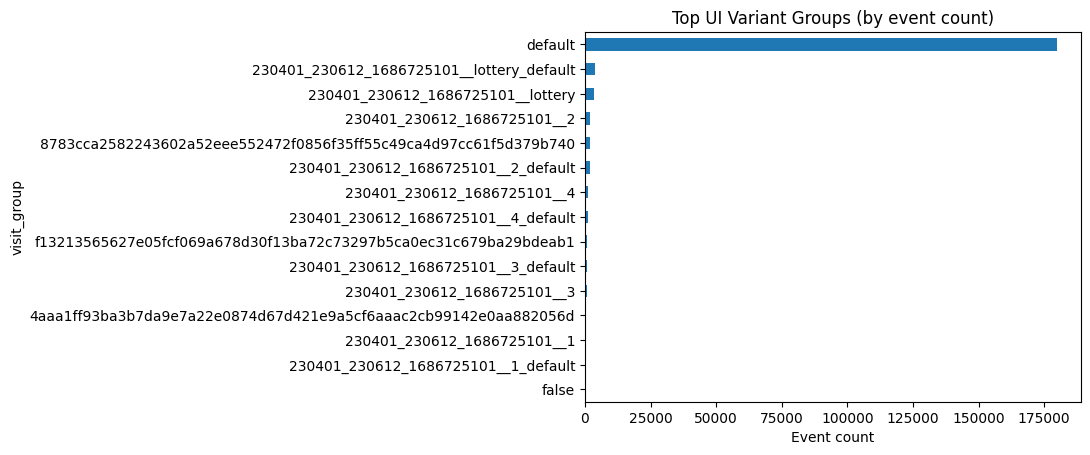

In [10]:
top_k = 15
plt.figure()
group_counts_events.head(top_k).sort_values().plot(kind="barh")
plt.title("Top UI Variant Groups (by event count)")
plt.xlabel("Event count")
plt.ylabel("visit_group")
plt.show()


## 6. Session-level Table Construction

The experiment is evaluated at the **session level**.  
We therefore aggregate event-level logs into a session-level dataset aligned
with the experiment unit.

### Definitions
- **Default UI (control):** `visit_group == DEFAULT_GROUP`
- **High-intent conversion:** sessions containing actions in
  `HIGH_INTENT_ACTIONS`


In [11]:
# --- editable definitions ---
DEFAULT_GROUP = "default"
HIGH_INTENT_ACTIONS = {"selectSize", "miniCart"}

def safe_mode(x):
    m = x.mode()
    return m.iloc[0] if len(m) else np.nan

session = (
    df.groupby("session_token")
      .agg(
          user_id=("session_userId", safe_mode),
          ui_group=("visit_group", safe_mode),
          session_start=("visit_time", "min"),
          session_end=("visit_time", "max"),
          n_events=("visit_action", "size"),
          n_unique_actions=("visit_action", "nunique"),
      )
)

session["session_duration_sec"] = (
    session["session_end"] - session["session_start"]
).dt.total_seconds()

hi = (
    df.assign(is_hi=df["visit_action"].isin(HIGH_INTENT_ACTIONS))
      .groupby("session_token")["is_hi"]
      .any()
      .astype(int)
      .rename("converted_hi")
)

session = session.join(hi, how="left")
session["converted_hi"] = session["converted_hi"].fillna(0).astype(int)
session["is_treatment"] = (session["ui_group"] != DEFAULT_GROUP).astype(int)

session.head()


,user_id,ui_group,session_start,session_end,n_events,n_unique_actions,session_duration_sec,converted_hi,is_treatment
session_token,,,,,,,,,
1325679,NaN,default,2023-04-01 00:04:12,2023-04-01 00:04:12,1,0,0.0,0,0
1325691,NaN,default,2023-04-01 00:25:33,2023-04-01 00:25:33,1,0,0.0,0,0
1325701,NaN,default,2023-04-01 00:49:42,2023-04-01 00:49:42,1,0,0.0,0,0
1325705,NaN,default,2023-04-01 00:54:29,2023-04-01 00:54:29,1,0,0.0,0,0
1325706,NaN,default,2023-04-01 01:02:29,2023-04-01 01:02:29,1,0,0.0,0,0


In [14]:
# Control vs Treatment counts and proportions
counts = session["is_treatment"].value_counts().sort_index()

summary = pd.DataFrame({
    "count": counts,
    "proportion": counts / counts.sum()
})

summary.rename(index={0: "control_default", 1: "treatment_non_default"})



,count,proportion
is_treatment,,
control_default,91866,0.915392
treatment_non_default,8491,0.084608


## 7. Session-level Exposure Balance

A/B validity depends on **session counts per UI group**, not event counts.


In [20]:
session["ui_group"].value_counts().head(30)


ui_group
default                                                             91866
230401_230612_1686725101__lottery_default                            1609
230401_230612_1686725101__lottery                                    1527
230401_230612_1686725101__2                                           968
230401_230612_1686725101__2_default                                   886
8783cca2582243602a52eee552472f0856f35ff55c49ca4d97cc61f5d379b740      635
230401_230612_1686725101__4                                           496
230401_230612_1686725101__4_default                                   437
230401_230612_1686725101__3                                           436
230401_230612_1686725101__3_default                                   413
f13213565627e05fcf069a678d30f13ba72c73297b5ca0ec31c679ba29bdeab1      291
230401_230612_1686725101__1                                           285
230401_230612_1686725101__1_default                                   269
4aaa1ff93ba3b7da9e7a22e0874d6

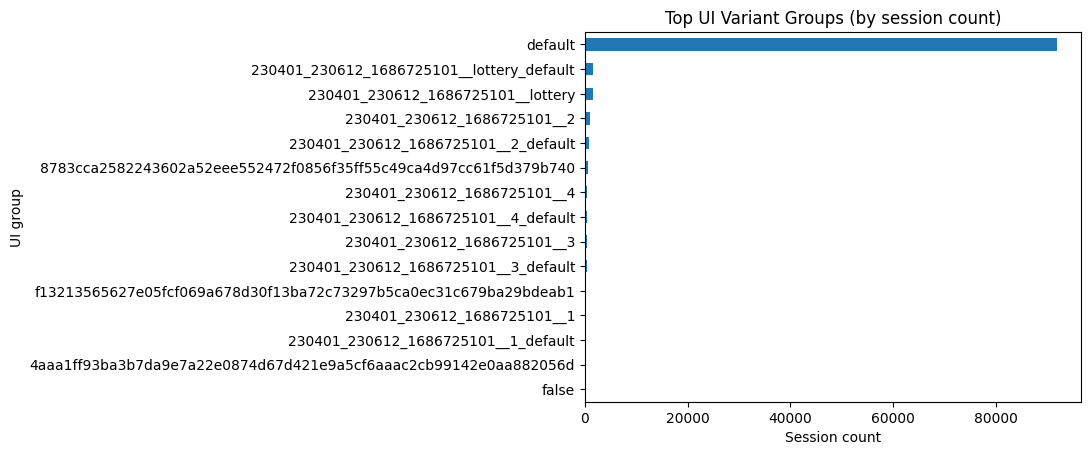

In [21]:
top_k = 15
plt.figure()
session["ui_group"].value_counts().head(top_k).sort_values().plot(kind="barh")
plt.title("Top UI Variant Groups (by session count)")
plt.xlabel("Session count")
plt.ylabel("UI group")
plt.show()


## 8. Engagement Distributions & Outliers

Engagement metrics are inspected to assess skewness and potential influence on
statistical testing and modeling.


In [22]:
session[["n_events", "n_unique_actions", "session_duration_sec"]].describe(
    percentiles=[.5, .75, .9, .95, .99]
).round(2)


,n_events,n_unique_actions,session_duration_sec
count,100357.00,100357.00,100357.00
mean,1.99,0.15,213.27
std,1.99,0.40,603.13
min,1.00,0.00,0.00
50%,1.00,0.00,0.00
75%,2.00,0.00,118.00
90%,4.00,1.00,625.00
95%,6.00,1.00,1241.00
99%,11.00,2.00,2965.88
max,27.00,5.00,24443.00


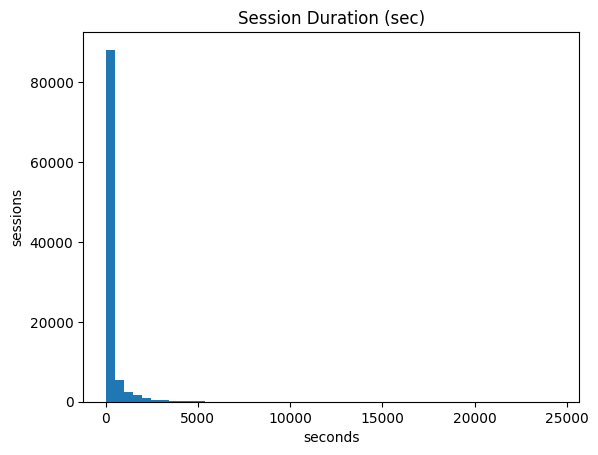

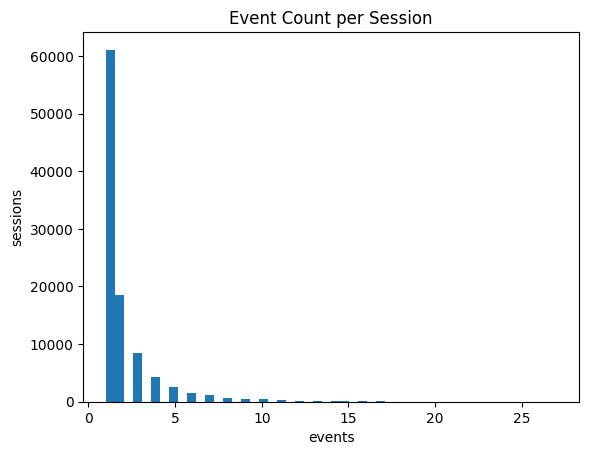

In [23]:
plt.figure()
plt.hist(session["session_duration_sec"].dropna(), bins=50)
plt.title("Session Duration (sec)")
plt.xlabel("seconds")
plt.ylabel("sessions")
plt.show()

plt.figure()
plt.hist(session["n_events"].dropna(), bins=50)
plt.title("Event Count per Session")
plt.xlabel("events")
plt.ylabel("sessions")
plt.show()


## 9. Engagement–Conversion Relationship (EDA only)

This analysis is descriptive and used to motivate sensitivity analyses and
heterogeneous treatment effect exploration.


In [24]:
session["converted_hi"].mean()


np.float64(0.04838725749075799)

In [25]:
session["events_q"] = pd.qcut(session["n_events"], q=5, duplicates="drop")
conv_by_q = (
    session.groupby("events_q")["converted_hi"]
           .agg(["size", "mean"])
           .reset_index()
           .rename(columns={"mean": "conv_rate"})
)
conv_by_q


C:\Users\YS\AppData\Local\Temp\ipykernel_27340\278025982.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session.groupby("events_q")["converted_hi"]


,events_q,size,conv_rate
0,"(0.999, 3.0]",88064,0.029467
1,"(3.0, 27.0]",12293,0.183926


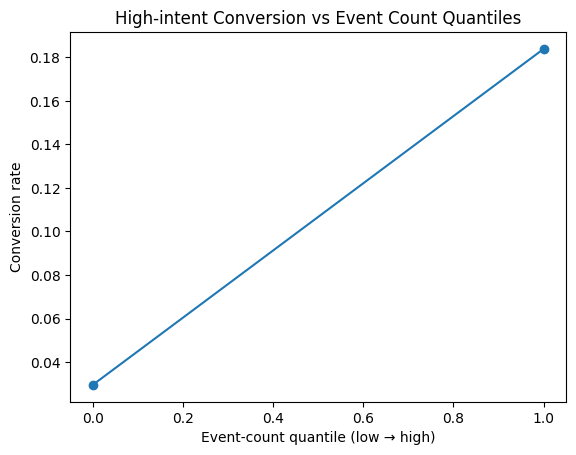

In [26]:
plt.figure()
plt.plot(range(len(conv_by_q)), conv_by_q["conv_rate"], marker="o")
plt.title("High-intent Conversion vs Event Count Quantiles")
plt.xlabel("Event-count quantile (low → high)")
plt.ylabel("Conversion rate")
plt.show()
